### **Crop Recommendation System using Machine Learning**

This Jupyter Notebook demonstrates a complete workflow for building a crop recommendation system based on environmental and soil parameters. The dataset `crop_recommendation.csv` contains features such as nitrogen (N), phosphorus (P), potassium (K), temperature, humidity, pH, and rainfall, along with the target crop labels.

On the datset we've applied supervised learning techniques for crop recommendation, highlighting model selection with best confidence score, evaluation and comparision of models and saving trained models.


#### **Data Loading and Exploration**

- Import necessary libraries (pandas, numpy, matplotlib, seaborn, scikit-learn).
- Load the dataset and perform initial exploration: view head, tail, shape, size, columns, unique labels, data types, and value counts.


In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn import metrics

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("../data/crop_recommendation.csv", low_memory=False)
print(f"✅ Crop recommendation dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns!")

✅ Crop recommendation dataset loaded successfully with 2200 rows and 8 columns!


In [4]:
# Explore the first few rows of the dataset
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
# Explore the last few rows of the dataset
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [6]:
# Check for missing values and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [7]:
# Get summary statistics of the dataset
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


#### **Data Visualization**

- Explore the distribution of numerical features using histograms.
- Generate a heatmap to visualize correlations between numerical features.


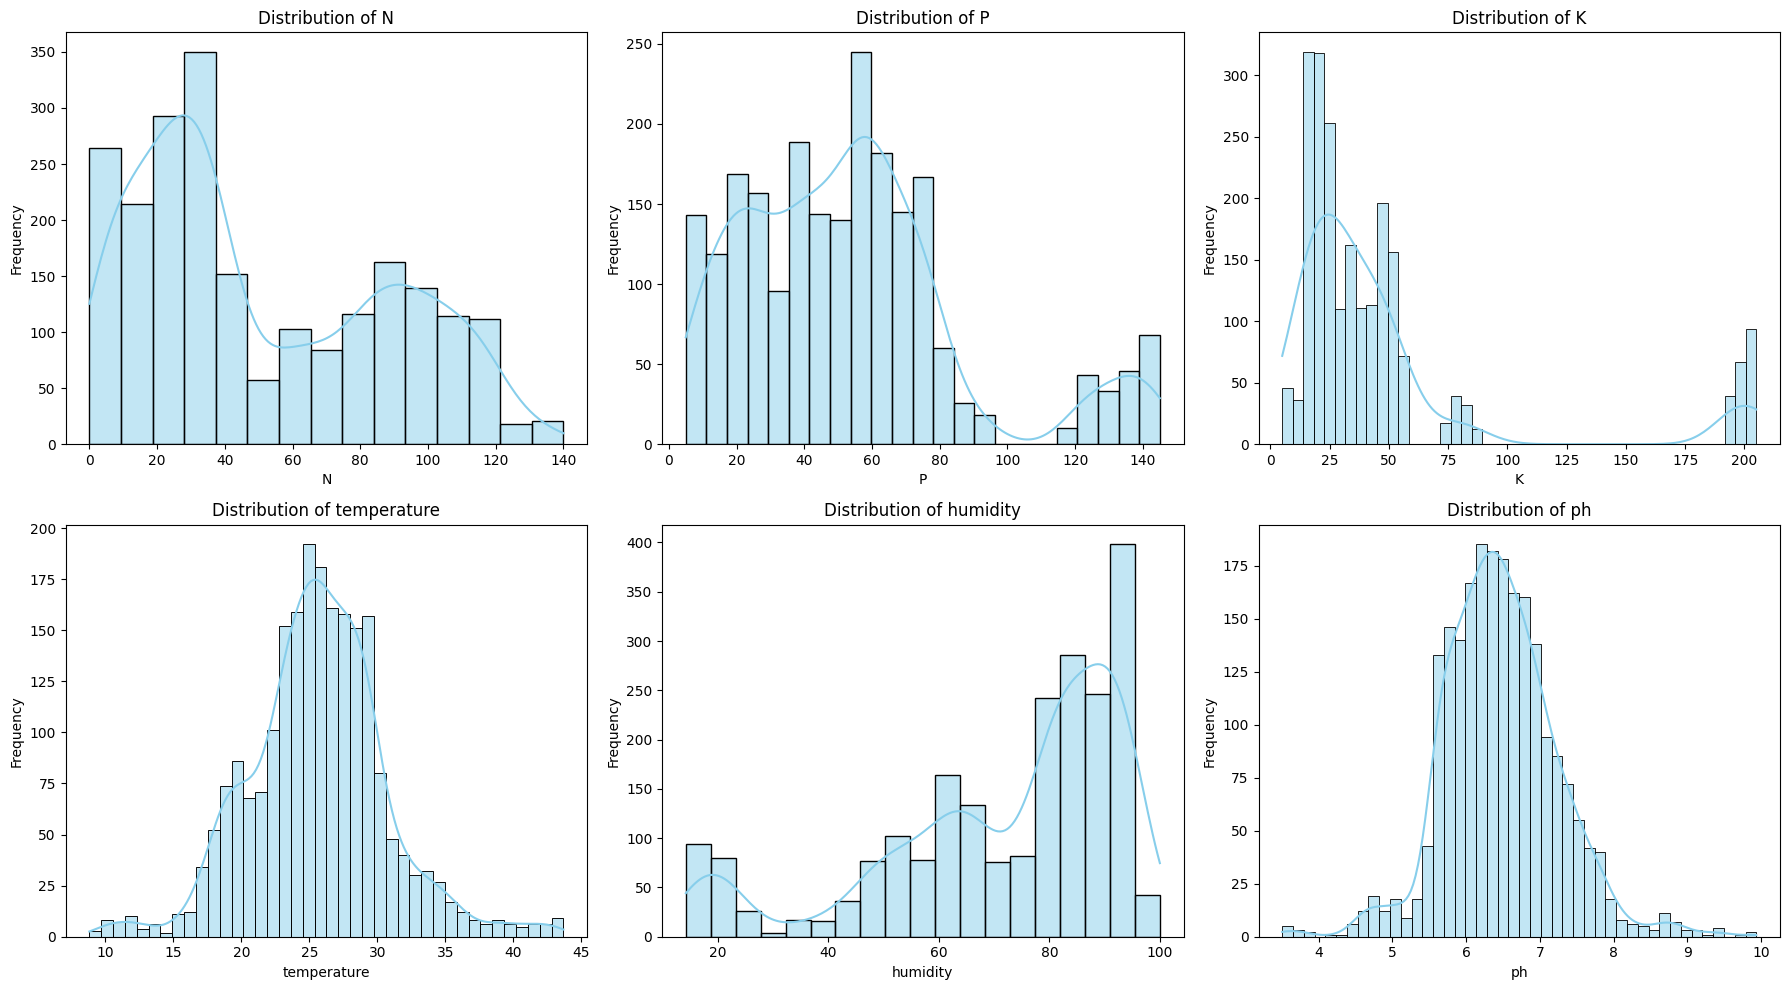

In [8]:
# Visualize the distribution of numerical features using
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
numerical_features = ["N", "P", "K", "temperature", "humidity", "ph"]

for i, feature in enumerate(numerical_features):
    ax = axes.flat[i]
    sns.histplot(df[feature], ax=ax, kde=True, color="skyblue")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

<Axes: >

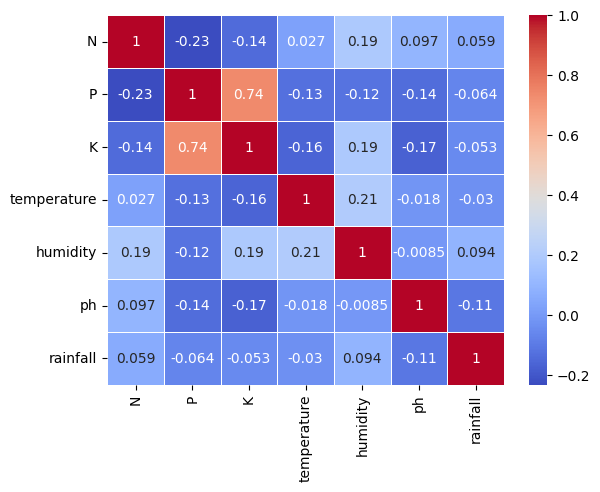

In [9]:
# Heatmap to visualize correlation between numerical features
sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
)

#### **Feature Engineering**

- Select relevant features and target variable for modeling.


In [10]:
# Prepare features and target variable for modeling
features = df[["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]]
target = df["label"]

In [11]:
# Initializing the empty dictionary to store model's name and its corresponding accuracy score
models_with_accuracy_scores = {}

#### **Splitting the Data**

- Split the dataset into training and testing sets using an 80-20 split.


In [12]:
# Splitting into train and test data
from sklearn.model_selection import train_test_split

Xtrain, Xtest, Ytrain, Ytest = train_test_split(features, target, test_size=0.2, random_state=2)

#### **Model Training and Evaluation**

- Train and evaluate multiple machine learning models:
  - Decision Tree Classifier
  - Naive Bayes (GaussianNB)
  - Support Vector Machine (SVM)
  - Logistic Regression
  - Random Forest Classifier
- For each model, compute accuracy, print classification reports, and perform cross-validation.
- Save trained models using pickle for future use.


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import pickle

##### **Decision Tree Classifier**

- Train the model and predict on the test set.
- Compute accuracy and classification report.
- Save the trained model using pickle.


In [14]:
# Train the Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(criterion="entropy", random_state=2, max_depth=5)
decision_tree_model.fit(Xtrain, Ytrain)

# Predicting the values for test data
predicted_values = decision_tree_model.predict(Xtest)
dt_accuracy = metrics.accuracy_score(Ytest, predicted_values)

# Perform cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(decision_tree_model, features, target, cv=5)

# Add the model name, accuracy score, and cross-validation accuracy to the models dictionary
models_with_accuracy_scores["Decision Tree"] = {
    "accuracy": dt_accuracy,
    "cross_val_accuracy": float(np.mean(cross_val_scores)),
}

# Print classification report for Decision Tree Classifier
print("🔍 Decision Tree Classifier - Classification Report:")
pd.DataFrame(classification_report(Ytest, predicted_values, output_dict=True)).transpose()

🔍 Decision Tree Classifier - Classification Report:


,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,13.0
banana,1.000000,1.000000,1.000000,17.0
blackgram,0.592593,1.000000,0.744186,16.0
chickpea,1.000000,1.000000,1.000000,21.0
coconut,0.913043,1.000000,0.954545,21.0
coffee,1.000000,1.000000,1.000000,22.0
cotton,1.000000,1.000000,1.000000,20.0
grapes,1.000000,1.000000,1.000000,18.0
jute,0.742857,0.928571,0.825397,28.0
kidneybeans,0.000000,0.000000,0.000000,14.0


In [15]:
# Dump the trained Decision Tree Classifier with Pickle
dt_pkl_filepath = "../pkl_objects/DecisionTree.pkl"

# Save the model to disk
with open(dt_pkl_filepath, "wb") as dt_model_pkl:
    pickle.dump(decision_tree_model, dt_model_pkl)
    models_with_accuracy_scores["Decision Tree"]["location"] = dt_pkl_filepath
    print(f"✅ Decision Tree Classifier model saved successfully at {dt_pkl_filepath}!")

✅ Decision Tree Classifier model saved successfully at ../pkl_objects/DecisionTree.pkl!


##### **Naive Bayes (Gaussian)**

- Train the model and predict on the test set.
- Compute accuracy and classification report.
- Save the trained model using pickle.


In [16]:
# Train the Gaussian Naive Bayes Classifier
gaussian_naive_bayes_model = GaussianNB()
gaussian_naive_bayes_model.fit(Xtrain, Ytrain)

# Predicting the values for test data
predicted_values = gaussian_naive_bayes_model.predict(Xtest)
gnb_accuracy = metrics.accuracy_score(Ytest, predicted_values)

# Perform cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(gaussian_naive_bayes_model, features, target, cv=5)

# Add the model name, accuracy score, and cross-validation accuracy to the models dictionary
models_with_accuracy_scores["Gaussian Naive Bayes"] = {
    "accuracy": gnb_accuracy,
    "cross_val_accuracy": float(np.mean(cross_val_scores)),
}

# Print classification report for Gaussian Naive Bayes
print("🔍 Gaussian Naive Bayes - Classification Report:")
pd.DataFrame(classification_report(Ytest, predicted_values, output_dict=True)).transpose()

🔍 Gaussian Naive Bayes - Classification Report:


,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,13.000000
banana,1.000000,1.000000,1.000000,17.000000
blackgram,1.000000,1.000000,1.000000,16.000000
chickpea,1.000000,1.000000,1.000000,21.000000
coconut,1.000000,1.000000,1.000000,21.000000
coffee,1.000000,1.000000,1.000000,22.000000
cotton,1.000000,1.000000,1.000000,20.000000
grapes,1.000000,1.000000,1.000000,18.000000
jute,0.875000,1.000000,0.933333,28.000000
kidneybeans,1.000000,1.000000,1.000000,14.000000


In [17]:
# Dump the trained Gaussian Naive Bayes Classifier with Pickle
gnb_pkl_filepath = "../pkl_objects/GaussianNB.pkl"

# Save the model to disk
with open(gnb_pkl_filepath, "wb") as gnb_model_pkl:
    pickle.dump(gaussian_naive_bayes_model, gnb_model_pkl)
    models_with_accuracy_scores["Gaussian Naive Bayes"]["location"] = gnb_pkl_filepath
    print(f"✅ Gaussian Naive Bayes model saved successfully at {gnb_pkl_filepath}!")

✅ Gaussian Naive Bayes model saved successfully at ../pkl_objects/GaussianNB.pkl!


##### **Support Vector Classifier (SVC)**

- Train the model and predict on the test set.
- Compute accuracy and classification report.
- Save the trained model using pickle.


In [18]:
# Train the SVC Classifier
svc_model = SVC(gamma="auto", random_state=2)
svc_model.fit(Xtrain, Ytrain)

# Predicting the values for test data
predicted_values = svc_model.predict(Xtest)
svc_accuracy = metrics.accuracy_score(Ytest, predicted_values)

# Perform cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(svc_model, features, target, cv=5)

# Add the model name, accuracy score, and cross-validation accuracy to the models dictionary
models_with_accuracy_scores["SVC"] = {
    "accuracy": svc_accuracy,
    "cross_val_accuracy": float(np.mean(cross_val_scores)),
}

# Print classification report for SVC
print("🔍 SVC - Classification Report:")
pd.DataFrame(classification_report(Ytest, predicted_values, output_dict=True)).transpose()

🔍 SVC - Classification Report:


,precision,recall,f1-score,support
apple,1.000000,0.230769,0.375000,13.000000
banana,1.000000,0.235294,0.380952,17.000000
blackgram,1.000000,0.187500,0.315789,16.000000
chickpea,1.000000,0.047619,0.090909,21.000000
coconut,1.000000,0.047619,0.090909,21.000000
coffee,0.000000,0.000000,0.000000,22.000000
cotton,1.000000,0.050000,0.095238,20.000000
grapes,1.000000,0.055556,0.105263,18.000000
jute,1.000000,0.071429,0.133333,28.000000
kidneybeans,0.034483,1.000000,0.066667,14.000000


In [19]:
# Dump the trained SVC Classifier with Pickle
svc_pkl_filepath = "../pkl_objects/SVC.pkl"

# Save the model to disk
with open(svc_pkl_filepath, "wb") as svc_model_pkl:
    pickle.dump(svc_model, svc_model_pkl)
    models_with_accuracy_scores["SVC"]["location"] = svc_pkl_filepath
    print(f"✅ SVC model saved successfully at {svc_pkl_filepath}!")

✅ SVC model saved successfully at ../pkl_objects/SVC.pkl!


##### **Logistic Regression**

- Train the model and predict on the test set.
- Compute accuracy and classification report.
- Save the trained model using pickle.


In [20]:
# Train the Logistic Regression Classifier
logistic_regression_model = LogisticRegression(random_state=2)
logistic_regression_model.fit(Xtrain, Ytrain)

# Predicting the values for test data
predicted_values = logistic_regression_model.predict(Xtest)
lr_accuracy = metrics.accuracy_score(Ytest, predicted_values)

# Perform cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(logistic_regression_model, features, target, cv=5)

# Add the model name, accuracy score, and cross-validation accuracy to the models dictionary
models_with_accuracy_scores["Logistic Regression"] = {
    "accuracy": lr_accuracy,
    "cross_val_accuracy": float(np.mean(cross_val_scores)),
}

# Print classification report for Logistic Regression
print("🔍 Logistic Regression - Classification Report:")
pd.DataFrame(classification_report(Ytest, predicted_values, output_dict=True)).transpose()

🔍 Logistic Regression - Classification Report:


,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,13.000000
banana,1.000000,1.000000,1.000000,17.000000
blackgram,0.857143,0.750000,0.800000,16.000000
chickpea,1.000000,1.000000,1.000000,21.000000
coconut,1.000000,1.000000,1.000000,21.000000
coffee,1.000000,1.000000,1.000000,22.000000
cotton,0.857143,0.900000,0.878049,20.000000
grapes,1.000000,1.000000,1.000000,18.000000
jute,0.838710,0.928571,0.881356,28.000000
kidneybeans,1.000000,1.000000,1.000000,14.000000


In [21]:
# Dump the trained Logistic Regression Classifier with Pickle
lr_pkl_filepath = "../pkl_objects/LogisticRegression.pkl"

# Save the model to disk
with open(lr_pkl_filepath, "wb") as lr_model_pkl:
    pickle.dump(logistic_regression_model, lr_model_pkl)
    models_with_accuracy_scores["Logistic Regression"]["location"] = lr_pkl_filepath
    print(f"✅ Logistic Regression model saved successfully at {lr_pkl_filepath}!")

✅ Logistic Regression model saved successfully at ../pkl_objects/LogisticRegression.pkl!


##### **Random Forest Classifier**

- Train the model and predict on the test set.
- Compute accuracy and classification report.
- Save the trained model using pickle.


In [22]:
# Train the Random Forest Classifier
random_forest_model = RandomForestClassifier(n_estimators=20, random_state=2)
random_forest_model.fit(Xtrain, Ytrain)

# Predicting the values for test data
predicted_values = random_forest_model.predict(Xtest)
rf_accuracy = metrics.accuracy_score(Ytest, predicted_values)

# Perform cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(random_forest_model, features, target, cv=5)

# Add the model name, accuracy score, and cross-validation accuracy to the models dictionary
models_with_accuracy_scores["Random Forest"] = {
    "accuracy": rf_accuracy,
    "cross_val_accuracy": float(np.mean(cross_val_scores)),
}

# Print classification report for Random Forest
print("🔍 Random Forest - Classification Report:")
pd.DataFrame(classification_report(Ytest, predicted_values, output_dict=True)).transpose()

🔍 Random Forest - Classification Report:


,precision,recall,f1-score,support
apple,1.000000,1.000000,1.000000,13.000000
banana,1.000000,1.000000,1.000000,17.000000
blackgram,1.000000,1.000000,1.000000,16.000000
chickpea,1.000000,1.000000,1.000000,21.000000
coconut,1.000000,1.000000,1.000000,21.000000
coffee,1.000000,1.000000,1.000000,22.000000
cotton,1.000000,1.000000,1.000000,20.000000
grapes,1.000000,1.000000,1.000000,18.000000
jute,0.870968,0.964286,0.915254,28.000000
kidneybeans,1.000000,1.000000,1.000000,14.000000


In [23]:
# Dump the trained Random Forest Classifier with Pickle
rf_pkl_filepath = "../pkl_objects/RandomForest.pkl"

# Save the model to disk
with open(rf_pkl_filepath, "wb") as rf_model_pkl:
    pickle.dump(random_forest_model, rf_model_pkl)
    models_with_accuracy_scores["Random Forest"]["location"] = rf_pkl_filepath
    print(f"✅ Random Forest model saved successfully at {rf_pkl_filepath}!")

✅ Random Forest model saved successfully at ../pkl_objects/RandomForest.pkl!


##### **Model Comparision**

Visualize the performance of machine learning models using a horizontal bar chart to compare their accuracies.

The chart clearly shows:

- Top performing ML models (with training accuracy > 90)
- Comparison between **training accuracy** and **cross-validation performance**


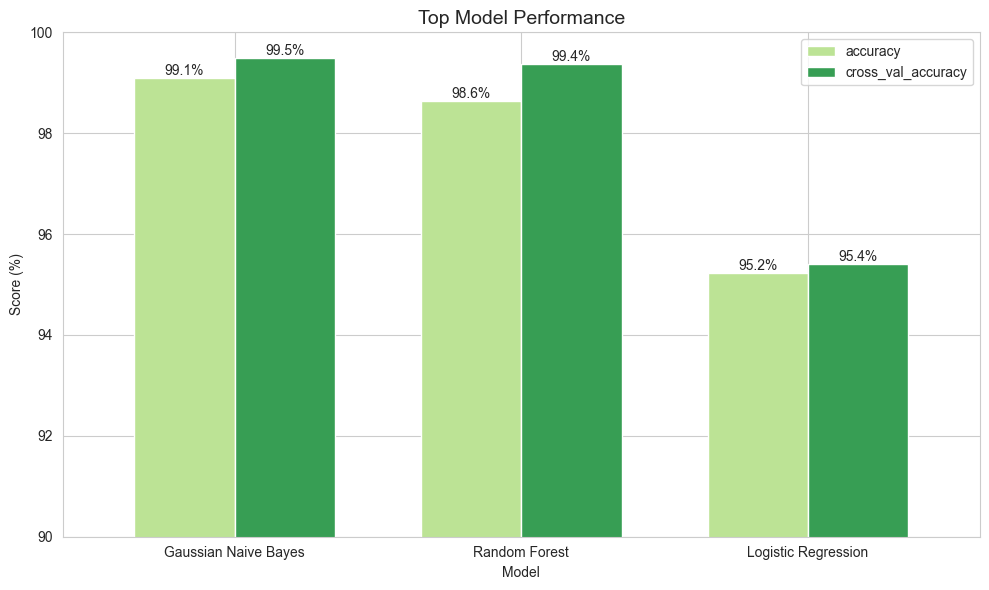

In [24]:
df = pd.DataFrame(models_with_accuracy_scores).T
df = df.sort_values(by="accuracy", ascending=False)

df_filtered = df[df["accuracy"] > 0.9]

df_filtered[["accuracy", "cross_val_accuracy"]] = (df_filtered[["accuracy", "cross_val_accuracy"]] * 100)

sns.set_style("whitegrid")
palette = sns.color_palette("YlGn", 2)

ax = df_filtered.plot(kind="bar", figsize=(10, 6), color=palette, width=0.7)

plt.ylim(90, 100)
plt.title("Top Model Performance", fontsize=14)
plt.ylabel("Score (%)")
plt.xlabel("Model")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.show()

#### **Make Predictions**

- Make sample predictions using best performing trained models with example test data.


In [25]:
# extract best performing models with accuracy > 90%
best_models = {
    model: details
    for model, details in models_with_accuracy_scores.items()
    if details["accuracy"] > 0.9
}

In [26]:
data_to_test = [
    {
        "N": 104,
        "P": 18,
        "K": 30,
        "temperature": 23.603016,
        "humidity": 60.3,
        "ph": 6.7,
        "rainfall": 140.91,
    },
    {
        "N": 83,
        "P": 45,
        "K": 60,
        "temperature": 28.0,
        "humidity": 70.3,
        "ph": 7.0,
        "rainfall": 150.9,
    },
    {
        "N": 60,
        "P": 35,
        "K": 40,
        "temperature": 26.5,
        "humidity": 65.2,
        "ph": 6.5,
        "rainfall": 120.4,
    },
    {
        "N": 90,
        "P": 40,
        "K": 50,
        "temperature": 27.8,
        "humidity": 68.1,
        "ph": 6.8,
        "rainfall": 135.7,
    },
    {
        "N": 70,
        "P": 30,
        "K": 45,
        "temperature": 25.4,
        "humidity": 62.5,
        "ph": 6.6,
        "rainfall": 110.2,
    },
    {
        "N": 110,
        "P": 50,
        "K": 65,
        "temperature": 29.1,
        "humidity": 72.0,
        "ph": 7.2,
        "rainfall": 160.3,
    },
    {
        "N": 95,
        "P": 42,
        "K": 55,
        "temperature": 24.9,
        "humidity": 66.4,
        "ph": 6.9,
        "rainfall": 145.6,
    },
    {
        "N": 75,
        "P": 28,
        "K": 38,
        "temperature": 22.7,
        "humidity": 59.8,
        "ph": 6.4,
        "rainfall": 100.5,
    },
    {
        "N": 88,
        "P": 36,
        "K": 48,
        "temperature": 27.0,
        "humidity": 67.3,
        "ph": 6.7,
        "rainfall": 130.8,
    },
    {
        "N": 102,
        "P": 47,
        "K": 58,
        "temperature": 28.5,
        "humidity": 71.2,
        "ph": 7.1,
        "rainfall": 155.4,
    },
]

In [27]:
results = []

for test_data in data_to_test:
    row = test_data.copy()

    test_df = pd.DataFrame([test_data])

    for model_name, details in best_models.items():
        with open(details["location"], "rb") as model_pkl:
            model = pickle.load(model_pkl)

        prediction = model.predict(test_df)[0]
        confidence = max(model.predict_proba(test_df)[0]) * 100
        row[model_name] = f"{prediction} (Confidence: {confidence:.1f}%)"

    results.append(row)

results_df = pd.DataFrame(results)

results_df

,N,P,K,temperature,humidity,ph,rainfall,Gaussian Naive Bayes,Logistic Regression,Random Forest
0,104,18,30,23.603016,60.3,6.7,140.91,coffee (Confidence: 100.0%),coffee (Confidence: 100.0%),coffee (Confidence: 100.0%)
1,83,45,60,28.000000,70.3,7.0,150.90,jute (Confidence: 100.0%),jute (Confidence: 93.9%),jute (Confidence: 60.0%)
2,60,35,40,26.500000,65.2,6.5,120.40,coffee (Confidence: 59.0%),jute (Confidence: 97.5%),coffee (Confidence: 50.0%)
3,90,40,50,27.800000,68.1,6.8,135.70,jute (Confidence: 100.0%),jute (Confidence: 93.9%),coffee (Confidence: 40.0%)
4,70,30,45,25.400000,62.5,6.6,110.20,coffee (Confidence: 88.4%),jute (Confidence: 99.4%),coffee (Confidence: 30.0%)
5,110,50,65,29.100000,72.0,7.2,160.30,jute (Confidence: 99.9%),banana (Confidence: 92.4%),jute (Confidence: 55.0%)
6,95,42,55,24.900000,66.4,6.9,145.60,jute (Confidence: 100.0%),jute (Confidence: 66.9%),coffee (Confidence: 45.0%)
7,75,28,38,22.700000,59.8,6.4,100.50,coffee (Confidence: 100.0%),jute (Confidence: 86.1%),coffee (Confidence: 45.0%)
8,88,36,48,27.000000,67.3,6.7,130.80,jute (Confidence: 99.8%),jute (Confidence: 94.6%),coffee (Confidence: 45.0%)
9,102,47,58,28.500000,71.2,7.1,155.40,jute (Confidence: 100.0%),jute (Confidence: 60.8%),jute (Confidence: 55.0%)
